In [4]:
from visualise import visualise, load_model

In [3]:
import os
root_path = os.path.abspath("./predictions")
print(root_path)

c:\Users\mokrota\Documents\GitHub\Neural-Network-Project\project\predictions


In [10]:
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import EMNIST
import torchvision.transforms as transforms

to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), transforms.ToTensor()
])
dataset = EMNIST(root="data_emnist", split="letters", train=False, transform=to_tensor)

In [8]:
model_path = os.path.abspath("./best_models/best_pyramid/cnn20.pth")
metadata_path = os.path.abspath("./best_models/best_pyramid/train_metadata20.json")
r_model_path = os.path.abspath("./best_models/best_reverse_pyramid/cnn10.pth")
r_metadata_path = os.path.abspath("./best_models/best_reverse_pyramid/train_metadata10.json")
model = load_model(model_path=model_path, metadata_path=metadata_path)
r_model = load_model(model_path=r_model_path, metadata_path=r_metadata_path)

In [ ]:
save_path_root = os.path.abspath("./predictions/emnist")

In [ ]:
def filter_dataset(dataset, label: int):
    filtered_i = [i for i, label in enumerate(dataset.targets) if label in int_combo]
    filtered_dataset = Subset(dataset, filtered_i)
    return filtered_dataset

In [19]:
import torch
def filter_misclassified_samples(model, dataset, condition):
    # condition is function that takes (predicted_label, true_label) and return bool
    device = torch.device("cuda")
    model.to(device)
    model.eval()
    
    filter_i = []

    dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1) + 1

            offset = i * dataloader.batch_size
            for j, (pred, true_label) in enumerate(zip(predictions, labels)):
                if condition(pred.item(), true_label.item()):
                    filter_i.append(offset + j)
    
    return Subset(dataset, filter_i)

In [17]:
def get_label(l):
    return ord(l) - ord('a') + 1

In [20]:
model = load_model(model_path, metadata_path)
tmp = filter_misclassified_samples(model=model, dataset=dataset, condition=lambda p, t: p == get_label("i") and t == get_label("l"))

In [21]:
print(len(tmp))

201


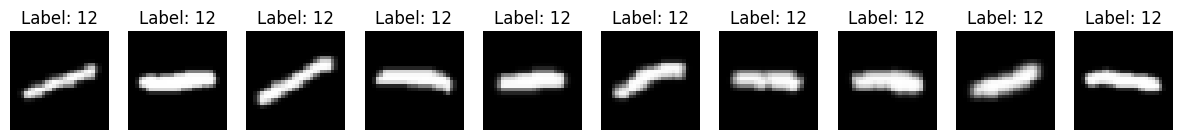

9 12


In [ ]:
# GPT GENERATED
import matplotlib.pyplot as plt

def show_images(dataset, num_samples=10):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

    # Ensure `axes` is a list (even if there's only 1 image)
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        image, label = dataset[i]

        # Convert Tensor to NumPy (if necessary)
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()  # Rearrange dimensions for matplotlib

        axes[i].imshow(image, cmap="gray")  # Display image
        axes[i].set_title(f"Label: {label}")
        axes[i].axis("off")

    plt.show()

# Example usage (display first 10 images)
show_images(tmp, num_samples=10)
print(get_label("i"), get_label("l"))

In [ ]:
def visualise_combo(true_label: str, predicted_label: str, predictions, dataset, path, img_num=50):
    filter_dataset = filter_misclassified_samples(model, dataset, lambda p, t: p == get_label(predicted_label) and t == get_label(true_label))
    dataloader = DataLoader(filter_dataset, batch_size=img_num, shuffle=False)
    return visualise(model, dataloader=dataloader, path=path)

In [ ]:
true_labels = ["d", "d",
               "g", "g",
               "i", "i",
               "l", "l"]
predicted_labels = ["d", "o", 
                    "g", "q",
                    "i", "l",
                    "l", "i"]

paths = [f"p:{p}_t:{t}" for p, t in zip(predicted_labels, true_labels)]

In [ ]:
for t_label, p_label, path in zip(true_labels, predicted_labels, paths):
    visualise_combo(t_label, p_label, model)